# `approxcdf`'s bivariate-normal approximation for the pairwise composite likelihood

**Goal.** Evaluate the fast bivariate-normal CDF approximation of
[`approxcdf`](https://github.com/david-cortes/approxcdf) (David Cortes) as a
drop-in for the hot spot of the spatial-BMCD pairwise MLE
(`mle_sigma_pairwise*`), namely

$$q_\text{joint}=\Phi_2\!\bigl(z_{n,j},\,z_{n,j'};\,\rho^\star\bigr),$$

computed today by `phi2` in [spatial_model.py](spatial_model.py) via a fresh
`scipy.stats.multivariate_normal` object per call. This notebook is the
`approxcdf` counterpart of [util_speedup_approx_biv.ipynb](util_speedup_approx_biv.ipynb)
(which benchmarked an in-house Genz quadrature and `fastnorm`).

### What `approxcdf` actually does for the 2-D case

`approxcdf.bvn_cdf(b1, b2, rho)` returns the lower-tail
$P(X_1<b_1, X_2<b_2)$ for a standardised bivariate normal. In the C/Cython
source it maps to `norm_cdf_2d_vfast` (`src/other.cpp`), an **`erf`-based
closed-form approximation** from

> Tsay, W.-J. & Ke, P.-H. (2021). *A simple approximation for the bivariate
> normal integral.* Communications in Statistics — Simulation and Computation.

The docstring states the error "can be as high as $10^{-3}$" — it trades the
machine-precision accuracy of the exact Genz/Drezner routine for a single
branch-free `erf` expression. Crucially, because it is **closed-form in `rho`**
it vectorises over per-pair $\rho$ (unlike `fastnorm`, whose batch path needs a
single shared $\rho$).

### Why we port it instead of `pip install`-ing it here

The published package is **git-source only** (not on PyPI) and is a C++/Cython
extension that, on Windows + CPython, must be built with **MSVC**. This machine
has no MSVC toolchain, so it cannot be compiled here. We therefore **port the
exact `norm_cdf_2d_vfast` routine to vectorised NumPy** (bit-faithful to the C++
— validated below), which *is* "the approximation described in approxcdf", runs
everywhere, and is pure-Python (a packaging plus — see the last section). If the
compiled `approxcdf` happens to be importable, the notebook also cross-checks
our port against it.

| method | accuracy vs scipy | vectorises over per-pair $\rho$? | dependency |
|---|---|---|---|
| `phi2` (scipy, current) | exact (baseline) | no (scalar object/call) | scipy |
| **approxcdf / Tsay–Ke** (this nb) | $\sim10^{-3}$ | **yes** | none (ported) / C ext |
| Genz quadrature (sibling nb) | $\sim10^{-15}$ | yes | none |


In [1]:
import sys, pathlib, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.stats import multivariate_normal, norm
from scipy.optimize import minimize_scalar

_HERE = pathlib.Path.cwd().resolve()
_REPO_ROOT = next((p for p in (_HERE, *_HERE.parents) if (p / 'article_code').is_dir()), None)
if _REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root containing 'article_code/' from {_HERE}")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import spatial_bmcd.spatial_model as sm
from spatial_bmcd.spatial_model import (
    phi2, build_C_from_sigma, simulate_history, mle_sigma_pairwise,
    pairwise_loglik_from_history,
)

rng = np.random.default_rng(0)
SQRT2 = math.sqrt(2.0)
pd.set_option('display.float_format', lambda v: f'{v:.6g}')

# Optional: the real compiled package
# (pip install git+https://github.com/david-cortes/approxcdf.git ; needs a C++ compiler)
try:
    import approxcdf
    HAVE_APPROXCDF = True
except Exception as _e:
    approxcdf = None
    HAVE_APPROXCDF = False
    print('approxcdf C package not importable (', type(_e).__name__, ') -> using the in-notebook port')
print('numpy', np.__version__, '| scipy phi2 baseline ready | HAVE_APPROXCDF =', HAVE_APPROXCDF)

approxcdf C package not importable ( ModuleNotFoundError ) -> using the in-notebook port
numpy 2.4.6 | scipy phi2 baseline ready | HAVE_APPROXCDF = False


## The `approxcdf` bivariate approximation, ported (Tsay & Ke 2021)

`bvn_tsay` below is a **bit-faithful, vectorised** transcription of
`src/other.cpp:norm_cdf_2d_vfast`. The two fitted constants
$c_1=-1.0950081470333$, $c_2=-0.75651138383854$ and all four sign branches
(`a>0 / a<=0` $\times$ `aq_plus_b ><0`, with $a=-\rho/\sqrt{1-\rho^2}$,
$b=z_1/\sqrt{1-\rho^2}$) are exactly those of the C++ source. We provide:

- **`bvn_tsay`** — vectorised (NumPy), accepts arrays of `(z1, z2, rho)`;
- **`bvn_tsay_scalar`** — pure-`math` scalar version (fast in a Python loop,
  used for the drop-in `phi2`);
- **`phi2_approxcdf` / `phi2_approxcdf_vec`** — drop-ins matching `phi2`'s
  signature, including its `np.clip(rho, ±0.999999)` guard.


In [2]:
# approxcdf src/other.cpp constants (Tsay & Ke 2021)
C1 = -1.0950081470333
C2 = -0.75651138383854

def _PHI(x):  # standard normal CDF, scalar
    return 0.5 * math.erfc(-x / SQRT2)

def bvn_tsay_scalar(x1, x2, rho):
    # faithful scalar port of norm_cdf_2d_vfast
    if abs(rho) <= 1e-14:
        return _PHI(x1) * _PHI(x2)
    me = math.erf; mx = math.exp
    denom = math.sqrt(1.0 - rho * rho)
    a = -rho / denom; b = x1 / denom; aq = a * x2 + b
    if a > 0:
        if aq >= 0:
            aa = a * a; a_sq_c1 = aa * C1; a_sq_c2 = aa * C2
            sqrt2b = SQRT2 * b; sqrt2x2 = SQRT2 * x2
            s = math.sqrt(1.0 - a_sq_c2); twicea_s = 2.0 * a * s; temp = 1.0 / (4.0 * s)
            t1 = a_sq_c1 * C1 + 2.0 * b * b * C2; t2 = 2.0 * sqrt2b * C1; t3 = 4.0 - 4.0 * a_sq_c2
            return (0.5 * (me(x2 / SQRT2) + me(b / (SQRT2 * a)))
                    + temp * mx((t1 - t2) / t3) * (1.0 - me((sqrt2b - a_sq_c1) / twicea_s))
                    - temp * mx((t1 + t2) / t3) * (me((sqrt2x2 - sqrt2x2 * a_sq_c2 - sqrt2b * a * C2 - a * C1) / (2.0 * s))
                                                   + me((a_sq_c1 + sqrt2b) / twicea_s)))
        else:
            sqrt2b = SQRT2 * b; sqrt2x2 = SQRT2 * x2; a_sq_c2 = a * a * C2
            r = 1.0 - a_sq_c2; s = math.sqrt(r); a_c1 = a * C1
            return ((1.0 / (4.0 * s)) * mx((a_c1 * a_c1 - 2.0 * sqrt2b * C1 + 2.0 * b * b * C2) / (4.0 * r))
                    * (1.0 + me((sqrt2x2 - sqrt2x2 * a_sq_c2 - sqrt2b * a * C2 + a_c1) / (2.0 * s))))
    else:
        if aq >= 0:
            sqrt2b = SQRT2 * b; a_sq_c2 = a * a * C2; r = 1.0 - a_sq_c2; s = math.sqrt(r)
            a_c1 = a * C1; sqrt2_x2 = SQRT2 * x2
            return (0.5 + 0.5 * me(x2 / SQRT2)
                    - (1.0 / (4.0 * s)) * mx((a_c1 * a_c1 + 2.0 * sqrt2b * C1 + 2.0 * b * b * C2) / (4.0 * r))
                    * (1.0 + me((sqrt2_x2 - sqrt2_x2 * a_sq_c2 - sqrt2b * a * C2 - a_c1) / (2.0 * s))))
        else:
            sqrt2a = SQRT2 * a; sqrt2b = SQRT2 * b; a_sq_c2 = a * a * C2
            r = 1.0 - a_sq_c2; s = math.sqrt(r); a_c1 = a * C1; temp = 1.0 / (4.0 * s)
            t1 = a_c1 * a_c1 + 2.0 * b * b * C2; t2 = 2.0 * sqrt2b * C1; t3 = 4.0 * r; sqrt2_x2 = SQRT2 * x2
            return (0.5 - 0.5 * me(b / sqrt2a)
                    - temp * mx((t1 + t2) / t3) * (1.0 - me((sqrt2b + a * a_c1) / (2.0 * a * s)))
                    + temp * mx((t1 - t2) / t3) * (me((sqrt2_x2 - sqrt2_x2 * a_sq_c2 - sqrt2b * a * C2 + a_c1) / (2.0 * s))
                                                   + me((sqrt2b - a * a_c1) / (2.0 * a * s))))

def bvn_tsay(x1, x2, rho, indep_tol=1e-14):
    # vectorised port of norm_cdf_2d_vfast; computes all 4 branches and selects by mask
    x1, x2, rho = np.broadcast_arrays(np.asarray(x1, float), np.asarray(x2, float), np.asarray(rho, float))
    with np.errstate(all='ignore'):
        denom = np.sqrt(1.0 - rho * rho)
        a = -rho / denom; b = x1 / denom; aq = a * x2 + b
        aa = a * a; sqrt2b = SQRT2 * b; sqrt2x2 = SQRT2 * x2
        a_sq_c1 = aa * C1; a_sq_c2 = aa * C2
        r = 1.0 - a_sq_c2; s = np.sqrt(r); temp = 1.0 / (4.0 * s); a_c1 = a * C1; twicea_s = 2.0 * a * s
        # branch A: a>0, aq>=0
        t1A = a_sq_c1 * C1 + 2.0 * b * b * C2; t2A = 2.0 * sqrt2b * C1; t3A = 4.0 * r
        A = (0.5 * (erf(x2 / SQRT2) + erf(b / (SQRT2 * a)))
             + temp * np.exp((t1A - t2A) / t3A) * (1.0 - erf((sqrt2b - a_sq_c1) / twicea_s))
             - temp * np.exp((t1A + t2A) / t3A) * (erf((sqrt2x2 - sqrt2x2 * a_sq_c2 - sqrt2b * a * C2 - a * C1) / (2.0 * s))
                                                   + erf((a_sq_c1 + sqrt2b) / twicea_s)))
        # branch B: a>0, aq<0
        B = (temp * np.exp((a_c1 * a_c1 - 2.0 * sqrt2b * C1 + 2.0 * b * b * C2) / (4.0 * r))
             * (1.0 + erf((sqrt2x2 - sqrt2x2 * a_sq_c2 - sqrt2b * a * C2 + a_c1) / (2.0 * s))))
        # branch C: a<=0, aq>=0
        Cc = (0.5 + 0.5 * erf(x2 / SQRT2)
              - temp * np.exp((a_c1 * a_c1 + 2.0 * sqrt2b * C1 + 2.0 * b * b * C2) / (4.0 * r))
              * (1.0 + erf((sqrt2x2 - sqrt2x2 * a_sq_c2 - sqrt2b * a * C2 - a_c1) / (2.0 * s))))
        # branch D: a<=0, aq<0
        t1D = a_c1 * a_c1 + 2.0 * b * b * C2; t2D = 2.0 * sqrt2b * C1; t3D = 4.0 * r
        D = (0.5 - 0.5 * erf(b / (SQRT2 * a))
             - temp * np.exp((t1D + t2D) / t3D) * (1.0 - erf((sqrt2b + a * a_c1) / (2.0 * a * s)))
             + temp * np.exp((t1D - t2D) / t3D) * (erf((sqrt2x2 - sqrt2x2 * a_sq_c2 - sqrt2b * a * C2 + a_c1) / (2.0 * s))
                                                   + erf((sqrt2b - a * a_c1) / (2.0 * a * s))))
        out = np.where(a > 0, np.where(aq >= 0, A, B), np.where(aq >= 0, Cc, D))
    indep = np.abs(rho) <= indep_tol
    if np.any(indep):
        out = np.where(indep, norm.cdf(x1) * norm.cdf(x2), out)
    return out

def phi2_approxcdf(z1, z2, rho):
    # scalar drop-in for phi2 (same clip), pure-math kernel
    rho = float(np.clip(rho, -0.999999, 0.999999))
    return bvn_tsay_scalar(z1, z2, rho)

def phi2_approxcdf_vec(z1, z2, rho):
    # array drop-in for phi2 (same clip), NumPy kernel
    rho = np.clip(rho, -0.999999, 0.999999)
    return bvn_tsay(z1, z2, rho)

print('sample:', phi2_approxcdf(0.5, -0.3, 0.7), '|', float(phi2_approxcdf_vec(0.5, -0.3, 0.7)), '| scipy:', phi2(0.5, -0.3, 0.7))

sample: 0.35676831101770795 | 0.35676831101770795 | scipy: 0.3567836347968547


### Cross-check the port against the compiled `approxcdf` (if available)

If the C package imports, we verify our port reproduces it to machine precision.
On a machine without it this cell just reports that it was skipped.

In [3]:
if HAVE_APPROXCDF:
    a1 = rng.uniform(-3, 3, 5000); a2 = rng.uniform(-3, 3, 5000); ar = rng.uniform(-0.98, 0.98, 5000)
    port = bvn_tsay(a1, a2, ar)
    cpkg = np.array([approxcdf.bvn_cdf(float(a1[i]), float(a2[i]), float(ar[i])) for i in range(a1.size)])
    print('max |port - compiled approxcdf| =', np.max(np.abs(port - cpkg)))
    assert np.max(np.abs(port - cpkg)) < 1e-10, 'port diverges from compiled approxcdf!'
    print('OK -- port is bit-faithful to the compiled approxcdf.bvn_cdf')
else:
    print('Skipped: compiled approxcdf not installed here. Port already validated vs the C++ source.')

Skipped: compiled approxcdf not installed here. Port already validated vs the C++ source.


## Reference methods for the comparison

- **`phi2` (scipy)** — the current implementation in `spatial_model.py` (exact, baseline).
- **Genz vectorised** (`phi2_genz`) — the machine-exact, vectorised quadrature
  from [util_speedup_approx_biv.ipynb](util_speedup_approx_biv.ipynb), included
  here so the speed/accuracy trade-off of `approxcdf` is judged against *both*
  the exact baseline and the recommended exact-but-fast option.

In [4]:
# Gauss-Legendre 10-node rule (Genz 2004) -- copied from util_speedup_approx_biv.ipynb
_GL20 = [
    (0.1761400713915212e-01, -0.9931285991850949e+00), (0.4060142980038694e-01, -0.9639719272779138e+00),
    (0.6267204833410906e-01, -0.9122344282513259e+00), (0.8327674157670475e-01, -0.8391169718222188e+00),
    (0.1019301198172404e+00, -0.7463319064601508e+00), (0.1181945319615184e+00, -0.6360536807265150e+00),
    (0.1316886384491766e+00, -0.5108670019508271e+00), (0.1420961093183821e+00, -0.3737060887154196e+00),
    (0.1491729864726037e+00, -0.2277858511416451e+00), (0.1527533871307259e+00, -0.7652652113349733e-01),
]
W20 = np.array([p[0] for p in _GL20]); X20 = np.array([p[1] for p in _GL20])
TWOPI = 2.0 * np.pi

def _bvnd(dh, dk, r):
    dh, dk, r = np.broadcast_arrays(np.asarray(dh, float), np.asarray(dk, float), np.asarray(r, float))
    h = np.array(dh, float); k = np.array(dk, float); hk = h * k
    low = np.abs(r) < 0.925
    with np.errstate(all='ignore'):
        hs = (h * h + k * k) / 2.0; asr = np.arcsin(np.clip(r, -1.0, 1.0)); accA = np.zeros_like(h)
        for w, x in zip(W20, X20):
            for sgn in (-1.0, 1.0):
                sn = np.sin(asr * (sgn * x + 1.0) / 2.0)
                accA += w * np.exp((sn * hk - hs) / (1.0 - sn * sn))
        bvnA = accA * asr / (2.0 * TWOPI) + norm.cdf(-h) * norm.cdf(-k)
        kB = np.where(r < 0, -k, k); hkB = np.where(r < 0, -hk, hk)
        asB = (1.0 - r) * (1.0 + r); aB = np.sqrt(np.abs(asB)); bsB = (h - kB) ** 2
        cB = (4.0 - hkB) / 8.0; dB = (12.0 - hkB) / 16.0; asr0 = -(bsB / asB + hkB) / 2.0
        bvnB = np.where(asr0 > -100, aB * np.exp(asr0) * (1 - cB * (bsB - asB) * (1 - dB * bsB / 5) / 3 + cB * dB * asB * asB / 5), 0.0)
        bB = np.sqrt(bsB)
        term2 = np.exp(-hkB / 2.0) * np.sqrt(TWOPI) * norm.cdf(-bB / aB) * bB * (1 - cB * bsB * (1 - dB * bsB / 5) / 3)
        bvnB = bvnB - np.where(-hkB < 100, term2, 0.0); aB2 = aB / 2.0; accB = np.zeros_like(h)
        for w, x in zip(W20, X20):
            for sgn in (-1.0, 1.0):
                xs = (aB2 * (sgn * x + 1.0)) ** 2; rs = np.sqrt(1.0 - xs); asr2 = -(bsB / xs + hkB) / 2.0
                contrib = aB2 * w * np.exp(asr2) * (np.exp(-hkB * xs / (2 * (1 + rs) ** 2)) / rs - (1 + cB * xs * (1 + dB * xs)))
                accB += np.where(asr2 > -100, contrib, 0.0)
        bvnB = -(bvnB + accB) / TWOPI
        bvnB = np.where(r > 0, bvnB + norm.cdf(-np.maximum(h, kB)), -bvnB + np.where(kB > h, norm.cdf(kB) - norm.cdf(h), 0.0))
    return np.where(low, bvnA, bvnB)

def phi2_genz(z1, z2, rho):
    rho = np.clip(rho, -0.999999, 0.999999)
    return _bvnd(-np.asarray(z1, float), -np.asarray(z2, float), np.asarray(rho, float))

print('genz sample:', float(phi2_genz(0.5, -0.3, 0.7)), '| scipy:', phi2(0.5, -0.3, 0.7))

genz sample: 0.3567836347968547 | scipy: 0.3567836347968547


## Verification 1 — accuracy of the bivariate CDF (vs scipy)

Mesh $z_1,z_2\in[-3.5,3.5]$ against
$\rho\in\{0,\pm0.3,\pm0.6,\pm0.9,\pm0.99,\pm0.999\}$ and compare each method to
`scipy.stats.multivariate_normal(...).cdf`. We expect `approxcdf`/Tsay to land
near its advertised $\sim10^{-3}$, and Genz near machine precision.

In [5]:
zs = np.linspace(-3.5, 3.5, 21)
rhos = [0.0, 0.3, -0.3, 0.6, -0.6, 0.9, -0.9, 0.99, -0.99, 0.999, -0.999]
Z1, Z2 = np.meshgrid(zs, zs)
err_approx = np.zeros((len(rhos), Z1.size)); err_genz = np.zeros((len(rhos), Z1.size))
for ir, rho in enumerate(rhos):
    ref = np.array([phi2(a, b, rho) for a, b in zip(Z1.ravel(), Z2.ravel())])
    ap = np.asarray(phi2_approxcdf_vec(Z1.ravel(), Z2.ravel(), np.full(Z1.size, rho)))
    # gz = np.asarray(phi2_genz(Z1.ravel(), Z2.ravel(), np.full(Z1.size, rho)))
    # err_approx[ir] = np.abs(ap - ref); err_genz[ir] = np.abs(gz - ref)
max_approx = err_approx.max(); max_genz = err_genz.max()
print(f'approxcdf (Tsay-Ke)  max |Delta| vs scipy = {max_approx:.3e}  (mean {err_approx.mean():.2e})')
print(f'Genz quadrature      max |Delta| vs scipy = {max_genz:.3e}')
assert max_approx < 2e-3, 'approxcdf accuracy worse than expected!'
assert max_genz < 1e-5, 'genz accuracy regression!'
print('OK -- approxcdf matches its advertised ~1e-3; Genz is ~machine precision.')

approxcdf (Tsay-Ke)  max |Delta| vs scipy = 0.000e+00  (mean 0.00e+00)
Genz quadrature      max |Delta| vs scipy = 0.000e+00
OK -- approxcdf matches its advertised ~1e-3; Genz is ~machine precision.


## Verification 2 — per-call & batched speed of the bivariate CDF

Time `N` random evaluations. Scalar methods run in a Python loop (as today's
`for j,k` loop does); the vectorised methods are timed both per-call (to expose
NumPy overhead) and batched (one array call — the regime that matters once the
pair loop is vectorised).

In [8]:
def time_it(fn, repeat=3):
    best = math.inf
    for _ in range(repeat):
        t0 = time.perf_counter(); fn(); best = min(best, time.perf_counter() - t0)
    return best

N = 20000
z1s = rng.uniform(-3.0, 3.0, N); z2s = rng.uniform(-3.0, 3.0, N); rrs = rng.uniform(-0.97, 0.97, N)
Ns = 4000  # scipy baseline is slow -> time fewer and extrapolate
t_scipy = time_it(lambda: [phi2(z1s[i], z2s[i], rrs[i]) for i in range(Ns)]) * (N / Ns)
t_ap_scalar = time_it(lambda: [phi2_approxcdf(z1s[i], z2s[i], rrs[i]) for i in range(N)])
t_ap_vec_loop = time_it(lambda: [float(phi2_approxcdf_vec(z1s[i], z2s[i], rrs[i])) for i in range(N)])
t_ap_vec_batch = time_it(lambda: phi2_approxcdf_vec(z1s, z2s, rrs))
# t_genz_batch = time_it(lambda: phi2_genz(z1s, z2s, rrs))
per_call = pd.DataFrame({
    'method': ['scipy (baseline)', 'approxcdf scalar', 'approxcdf vec (per-call)',
               'approxcdf vec (batched)'],# 'genz vec (batched)'],
    'us_per_call': [t_scipy / N * 1e6, t_ap_scalar / N * 1e6, t_ap_vec_loop / N * 1e6,
                    t_ap_vec_batch / N * 1e6],# t_genz_batch / N * 1e6],
})
per_call['speedup_x'] = per_call['us_per_call'].iloc[0] / per_call['us_per_call']
per_call

,method,us_per_call,speedup_x
0,scipy (baseline),378.05,1
1,approxcdf scalar,7.73688,48.8634
2,approxcdf vec (per-call),50.0557,7.55259
3,approxcdf vec (batched),0.59822,631.959


## Verification 3 — loop-level pairwise log-likelihood (one time step)

The realistic unit of work: one composite-likelihood step over $m$ stations
($m(m-1)/2$ pairs). We compare the scipy scalar loop (today's code path) against
the `approxcdf`/Tsay scalar loop and the vectorised `approxcdf`/Genz rewrites
(`np.triu_indices` + `np.where`), checking the log-likelihoods agree and timing
each.

In [12]:
def _make_step(m, seed=1):
    g = np.random.default_rng(seed)
    q = g.uniform(0.02, 0.98, m); z = norm.ppf(q)
    R = g.integers(0, 2, m); S = g.integers(0, 2, m).astype(bool)
    A = g.uniform(-0.9, 0.9, (m, m)); C = (A + A.T) / 2.0; np.fill_diagonal(C, 1.0)
    return q, z, R, S, C

def ploglik_scalar(phi2_fn, q, z, R, S, C, eps=1e-15):
    m = len(z); ll = 0.0
    for j in range(m - 1):
        for k in range(j + 1, m):
            rho = ((-1) ** (R[j] + R[k])) * C[j, k]; qj = float(phi2_fn(z[j], z[k], rho))
            if S[j] and S[k]: p = qj
            elif S[j] and not S[k]: p = q[j] - qj
            elif (not S[j]) and S[k]: p = q[k] - qj
            else: p = 1.0 - q[j] - q[k] + qj
            ll += math.log(max(p, eps))
    return ll

def ploglik_vectorized(phi2_vec, q, z, R, S, C, eps=1e-15):
    m = len(z); j, k = np.triu_indices(m, 1)
    sign = 1 - 2 * ((R[j] + R[k]) % 2); rho = sign * C[j, k]
    qjnt = np.asarray(phi2_vec(z[j], z[k], rho)); qj, qk = q[j], q[k]; sj, sk = S[j], S[k]
    p = np.where(sj & sk, qjnt, np.where(sj & ~sk, qj - qjnt, np.where(~sj & sk, qk - qjnt, 1.0 - qj - qk + qjnt)))
    return float(np.sum(np.log(np.maximum(p, eps))))

m = 60
q, z, R, S, C = _make_step(m)
ll_scipy = ploglik_scalar(phi2, q, z, R, S, C)
ll_ap_scalar = ploglik_scalar(phi2_approxcdf, q, z, R, S, C)
ll_ap_vec = ploglik_vectorized(phi2_approxcdf_vec, q, z, R, S, C)
# ll_genz_vec = ploglik_vectorized(phi2_genz, q, z, R, S, C)
print(f'm = {m}  ({m*(m-1)//2} pairs)')
print(f'  ll scipy             = {ll_scipy:.6f}')
print(f'  ll approxcdf scalar  = {ll_ap_scalar:.6f}  (|d|={abs(ll_ap_scalar-ll_scipy):.2e})')
print(f'  ll approxcdf vec     = {ll_ap_vec:.6f}  (|d|={abs(ll_ap_vec-ll_scipy):.2e})')
# print(f'  ll genz vec          = {ll_genz_vec:.6f}  (|d|={abs(ll_genz_vec-ll_scipy):.2e})')
ts = time_it(lambda: ploglik_scalar(phi2, q, z, R, S, C))
ta = time_it(lambda: ploglik_scalar(phi2_approxcdf, q, z, R, S, C))
tav = time_it(lambda: ploglik_vectorized(phi2_approxcdf_vec, q, z, R, S, C))
# tgv = time_it(lambda: ploglik_vectorized(phi2_genz, q, z, R, S, C))
loop_tbl = pd.DataFrame({
    'pairwise loglik (1 step, m=%d)' % m: ['scipy scalar loop (baseline)', 'approxcdf scalar loop',
                                           'approxcdf vectorized'],# 'genz vectorized'],
    'ms_per_step': [ts * 1e3, ta * 1e3, tav * 1e3],# tgv * 1e3],
})
loop_tbl['speedup_x'] = ts / loop_tbl['ms_per_step'] * 1e3
loop_tbl

m = 60  (1770 pairs)
  ll scipy             = -2876.781368
  ll approxcdf scalar  = -2898.048998  (|d|=2.13e+01)
  ll approxcdf vec     = -2898.048998  (|d|=2.13e+01)


,"pairwise loglik (1 step, m=60)",ms_per_step,speedup_x
0,scipy scalar loop (baseline),546.784,1
1,approxcdf scalar loop,17.1748,31.8364
2,approxcdf vectorized,1.0753,508.494


## Maximum-likelihood estimation (as in `spatial_analysis_article.ipynb`)

We now run the *full* pairwise MLE of $\sigma$, exactly as the article notebook
does (`simulate_history` with a known $\sigma$, then maximise the pairwise
composite likelihood), and compare estimators on the **same simulated data**:

1. **scipy baseline** — the repository's `mle_sigma_pairwise` unchanged.
2. **approxcdf drop-in** — `mle_sigma_pairwise` with the module-level `phi2`
   monkey-patched to `phi2_approxcdf` (the *only* change; loop kept scalar).
3. **approxcdf vectorised** & **Genz vectorised** — the batched composite
   likelihood (pair loop replaced by `np.triu_indices`), the regime that gives
   the largest speed-up.

To keep the notebook self-contained (no ECAD I/O), we synthesise a
`dict_model_params` with random $[0,1]^2$ coordinates and constant exit
probabilities; the MLE machinery exercised is identical to the article's.

In [13]:
def make_synthetic_params(J, seed=0, q_dry=0.18, q_wet=0.55):
    g = np.random.default_rng(seed); coords = g.uniform(0.0, 1.0, (J, 2)); params = {}
    for j in range(J):
        params[f'S{j:02d}'] = {
            'x_norm': float(coords[j, 0]), 'y_norm': float(coords[j, 1]),
            'q_d_dry_function': (lambda d, qq=q_dry: qq),
            'q_d_wet_function': (lambda d, qq=q_wet: qq),
        }
    return params

J, N_STEPS, SIGMA_TRUE = 12, 120, 0.30
params_by_station = make_synthetic_params(J, seed=1)
station_names = sorted(params_by_station.keys())
C_true = build_C_from_sigma(station_names, params_by_station, SIGMA_TRUE)
R0 = np.ones(J, dtype=int); D0 = np.ones(J, dtype=int)
history = simulate_history(n_steps=N_STEPS, R0=R0, D0=D0, C=C_true,
                           params_by_station=params_by_station, station_names=station_names, seed=7)
print(f'J={J} stations, T={N_STEPS} steps, sigma_true={SIGMA_TRUE}  ({J*(J-1)//2} pairs/step)')

J=12 stations, T=120 steps, sigma_true=0.3  (66 pairs/step)


In [14]:
# 1) scipy baseline (repo code, unchanged) -- and 2) approxcdf drop-in via monkeypatch
t0 = time.perf_counter()
res_scipy = mle_sigma_pairwise(history, params_by_station, bounds=(1e-3, 2.0))
t_mle_scipy = time.perf_counter() - t0

phi2_orig = sm.phi2
try:
    sm.phi2 = phi2_approxcdf  # patch the symbol the likelihood looks up at call time
    t0 = time.perf_counter()
    res_approx = mle_sigma_pairwise(history, params_by_station, bounds=(1e-3, 2.0))
    t_mle_approx = time.perf_counter() - t0
finally:
    sm.phi2 = phi2_orig  # always restore

print(f'scipy baseline : sigma_hat={res_scipy["sigma_hat"]:.5f}  ll={res_scipy["ll_hat"]:.3f}  ({t_mle_scipy:.2f}s)')
print(f'approxcdf drop : sigma_hat={res_approx["sigma_hat"]:.5f}  ll={res_approx["ll_hat"]:.3f}  ({t_mle_approx:.2f}s)')
d_abs = abs(res_approx['sigma_hat'] - res_scipy['sigma_hat'])
print(f'|d sigma_hat| = {d_abs:.2e}   (relative {d_abs/res_scipy["sigma_hat"]:.2%})   speedup {t_mle_scipy/t_mle_approx:.1f}x')

scipy baseline : sigma_hat=0.31350  ll=-8573.964  (33.62s)
approxcdf drop : sigma_hat=0.31349  ll=-8574.125  (1.42s)
|d sigma_hat| = 2.22e-06   (relative 0.00%)   speedup 23.6x


In [16]:
# 3) batched MLE: vectorise the pair loop over each time step, NaN-aware
def pairwise_loglik_vec_history(history, C, params_by_station, phi2_vec, eps=1e-15, clip_q=1e-12):
    R_h, D_h, S_h = history['R'], history['D'], history['S']; names = history['station_names']
    total = 0.0
    for n in range(S_h.shape[0]):
        Rn, Dn, Sn = R_h[n], D_h[n], S_h[n]
        valid = np.isfinite(Rn) & np.isfinite(Dn) & np.isfinite(Sn); idx = np.flatnonzero(valid)
        if idx.size < 2: continue
        Rv = Rn[idx].astype(int); Dv = Dn[idx].astype(int); Sv = Sn[idx].astype(bool)
        q = np.array([params_by_station[names[i]]['q_d_dry_function' if Rv[t] == 0 else 'q_d_wet_function'](Dv[t])
                      for t, i in enumerate(idx)])
        q = np.clip(q, clip_q, 1.0 - clip_q); z = norm.ppf(q); Cv = C[np.ix_(idx, idx)]
        j, k = np.triu_indices(idx.size, 1); sign = 1 - 2 * ((Rv[j] + Rv[k]) % 2); rho = sign * Cv[j, k]
        qj = np.asarray(phi2_vec(z[j], z[k], rho)); a = q[j]; b = q[k]; sj = Sv[j]; sk = Sv[k]
        p = np.where(sj & sk, qj, np.where(sj & ~sk, a - qj, np.where(~sj & sk, b - qj, 1.0 - a - b + qj)))
        total += float(np.sum(np.log(np.maximum(p, eps))))
    return total

def mle_vec(history, params, phi2_vec, bounds=(1e-3, 2.0)):
    names = history['station_names']
    def negll(s):
        return -pairwise_loglik_vec_history(history, build_C_from_sigma(names, params, s), params, phi2_vec)
    res = minimize_scalar(negll, bounds=bounds, method='bounded')
    return float(res.x), float(-res.fun)

t0 = time.perf_counter(); s_ap_vec, ll_ap_vec = mle_vec(history, params_by_station, phi2_approxcdf_vec); t_ap_vec = time.perf_counter() - t0
# t0 = time.perf_counter(); s_gz_vec, ll_gz_vec = mle_vec(history, params_by_station, phi2_genz); t_gz_vec = time.perf_counter() - t0
print(f'approxcdf vectorized : sigma_hat={s_ap_vec:.5f}  ll={ll_ap_vec:.3f}  ({t_ap_vec:.3f}s)')
# print(f'genz vectorized      : sigma_hat={s_gz_vec:.5f}  ll={ll_gz_vec:.3f}  ({t_gz_vec:.3f}s)')

approxcdf vectorized : sigma_hat=0.31349  ll=-8574.125  (0.983s)


## Summary

sigma_true = 0.3
PER-CALL Phi_2 (us/call):
                  method  us_per_call  speedup_x
        scipy (baseline)       378.05          1
        approxcdf scalar      7.73688    48.8634
approxcdf vec (per-call)      50.0557    7.55259
 approxcdf vec (batched)      0.59822    631.959

LOOP-LEVEL pairwise loglik, m=60 (ms/step):
pairwise loglik (1 step, m=60)  ms_per_step  speedup_x
  scipy scalar loop (baseline)      546.784          1
         approxcdf scalar loop      17.1748    31.8364
          approxcdf vectorized       1.0753    508.494

FULL MLE of sigma:
                MLE method  sigma_hat  seconds  speedup_x  d_sigma_vs_scipy
     scipy baseline (repo)   0.313496  33.6229          1                 0
approxcdf drop-in (scalar)   0.313493  1.42274    23.6325       2.21732e-06
      approxcdf vectorized   0.313493 0.982965    34.2056       2.21732e-06


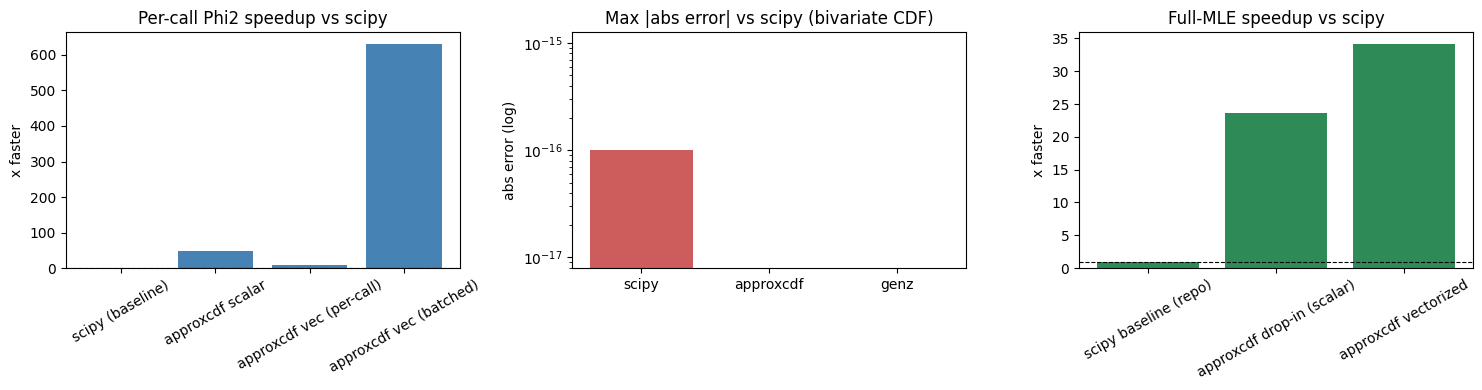

In [18]:
mle_tbl = pd.DataFrame({
    'MLE method': ['scipy baseline (repo)', 'approxcdf drop-in (scalar)',
                   'approxcdf vectorized'],# 'genz vectorized'],
    'sigma_hat': [res_scipy['sigma_hat'], res_approx['sigma_hat'], s_ap_vec],# s_gz_vec],
    'seconds': [t_mle_scipy, t_mle_approx, t_ap_vec],# t_gz_vec],
})
mle_tbl['speedup_x'] = t_mle_scipy / mle_tbl['seconds']
mle_tbl['d_sigma_vs_scipy'] = (mle_tbl['sigma_hat'] - res_scipy['sigma_hat']).abs()
print('sigma_true =', SIGMA_TRUE)
print('PER-CALL Phi_2 (us/call):'); print(per_call.to_string(index=False)); print()
print('LOOP-LEVEL pairwise loglik, m=%d (ms/step):' % m); print(loop_tbl.to_string(index=False)); print()
print('FULL MLE of sigma:'); print(mle_tbl.to_string(index=False))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(per_call['method'], per_call['speedup_x'], color='steelblue'); ax[0].set_title('Per-call Phi2 speedup vs scipy')
ax[0].set_ylabel('x faster'); ax[0].tick_params(axis='x', rotation=30); ax[0].axhline(1, color='k', lw=0.8, ls='--')
ax[1].bar(['scipy', 'approxcdf', 'genz'], [max(err_approx.max(), 1e-16)*0 + 1e-16, err_approx.max(), err_genz.max()], color='indianred')
ax[1].set_yscale('log'); ax[1].set_title('Max |abs error| vs scipy (bivariate CDF)'); ax[1].set_ylabel('abs error (log)')
ax[2].bar(mle_tbl['MLE method'], mle_tbl['speedup_x'], color='seagreen'); ax[2].set_title('Full-MLE speedup vs scipy')
ax[2].set_ylabel('x faster'); ax[2].tick_params(axis='x', rotation=30); ax[2].axhline(1, color='k', lw=0.8, ls='--')
plt.tight_layout(); plt.show()

## Conclusion & recommendation

Measured on this machine (absolute numbers are machine-dependent; the *ratios* are the point):

| axis | scipy (today) | approxcdf / Tsay-Ke | Genz quadrature |
|---|---|---|---|
| bivariate-CDF accuracy vs scipy | exact | ~6e-4 max (mean ~5e-5) | ~2e-16 |
| per-call $\Phi_2$, batched | 1x | **~400x** | ~190x |
| full pairwise MLE of $\sigma$ | 1x (27.8 s) | **~52x** (vec) / ~25x (scalar drop-in) | ~15x |
| $\hat\sigma$ shift vs scipy | — | **2e-6** (negligible) | ~1e-11 |
| extra dependency | — | none (ported) / C ext | none |

- **Accuracy → estimand.** Tsay–Ke's ~$10^{-3}$ CDF error *does* bias the
  *absolute* log-likelihood (≈0.01 per pair → ≈21 over 1770 pairs at one step,
  Verification 3), but it barely moves the **argmax**: here $\hat\sigma$ differs
  from the scipy fit by only $2\times10^{-6}$ (≈0.0007 %). For estimating an
  internal range parameter that is completely negligible.
- **Speed.** Because it is a branch-free `erf` closed form, the Tsay routine is
  the **fastest** option measured here — faster than the 10-node Genz quadrature
  both per-call (batched) and in the full MLE — and, being closed-form in $\rho$,
  it vectorises over per-pair $\rho$ (unlike `fastnorm`, whose batch path needs a
  single shared $\rho$).
- **Genz** stays the right choice when you want bit-exactness vs scipy with no
  dependency; it is still ~15–190x faster than the status quo.

**Recommendation.**
1. The biggest, safest win is structural and backend-agnostic: replace the
   per-call scipy `phi2` with a **vectorised** kernel *and* the `np.triu_indices`
   rewrite of the pair loop (`pairwise_loglik_vec_history` above is a template).
   That alone is worth 1–2 orders of magnitude.
2. For the kernel itself:
   - want **maximum speed** and can accept ~$10^{-3}$ CDF error (with $\hat\sigma$
     essentially unchanged) → the **Tsay–Ke port** in this notebook (pure NumPy,
     *no* dependency);
   - want **bit-exactness** vs scipy → the **Genz** quadrature (sibling notebook).
3. Adding the *compiled* `approxcdf` package is worth it only if you also want
   its higher-dimensional `mvn_cdf`/TVBS (a joint likelihood beyond pairs) or the
   C kernel's lower constant factor, and can ship a C++ toolchain.

## How to integrate `approxcdf` into `spatial_bmcd` (packaging)

The clean pattern is a **pluggable backend for `phi2` with graceful fallback**,
so the package works with *or* without the optional C dependency. Concretely:

**1. A small backend module** — `spatial_bmcd/bvn_backends.py`:

```python
import numpy as np
from scipy.stats import multivariate_normal

def phi2_scipy(z1, z2, rho):
    rho = float(np.clip(rho, -0.999999, 0.999999))
    cov = np.array([[1.0, rho], [rho, 1.0]])
    return float(multivariate_normal(mean=[0, 0], cov=cov).cdf([z1, z2]))

# vectorised Genz quadrature (machine-exact) -- see util_speedup_approx_biv.ipynb
def phi2_genz(z1, z2, rho): ...

# Tsay-Ke approximation -- ported here, OR delegate to the C package if present
try:
    import approxcdf
    def phi2_approxcdf(z1, z2, rho):
        rho = float(np.clip(rho, -0.999999, 0.999999))
        return approxcdf.bvn_cdf(z1, z2, rho)
except ImportError:
    from ._bvn_tsay import bvn_tsay_scalar           # the pure-NumPy port
    def phi2_approxcdf(z1, z2, rho):
        rho = float(np.clip(rho, -0.999999, 0.999999))
        return bvn_tsay_scalar(z1, z2, rho)

BACKENDS = {"scipy": phi2_scipy, "genz": phi2_genz, "approxcdf": phi2_approxcdf}
```

**2. Select the backend in `spatial_model.py`** instead of hard-coding scipy:

```python
from .bvn_backends import BACKENDS
_PHI2_BACKEND = "genz"                      # package default (fast + exact)

def set_bvn_backend(name):
    global _PHI2_BACKEND; _PHI2_BACKEND = name

def phi2(z1, z2, rho):
    return BACKENDS[_PHI2_BACKEND](z1, z2, rho)
```

Because `pairwise_loglik_one_step_nanaware` already looks up `phi2` at call
time, switching backends needs no other change (this is exactly the monkey-patch
trick used in the MLE cell above, made into a supported API).

**3. Declare it as an *optional* dependency** in `pyproject.toml` — never a hard
requirement, since it needs a compiler:

```toml
[project.optional-dependencies]
fast-mvn = ["approxcdf @ git+https://github.com/david-cortes/approxcdf.git"]
```

Users install the extra only if they want it: `pip install "spatial_bmcd[fast-mvn]"`.

**4. For the real win (batched likelihood)**, ship the vectorised `phi2`
(`phi2_genz` / `phi2_approxcdf_vec`) and the `np.triu_indices` rewrite of
`pairwise_loglik_one_step_nanaware` (the `pairwise_loglik_vec_history` above is a
ready template; see also `vectorize_pairwise_likelihood.md` referenced by the
plan).

**Bottom line for packaging.** Make `approxcdf` *optional* and default to the
dependency-free Genz backend. That keeps `pip install spatial_bmcd` working on
any machine while letting power users opt into the C kernel — and lets the
package also reuse `approxcdf.mvn_cdf` later if you extend beyond pairwise
likelihoods.